# 2026-2 COW AI팀 사전 과제 · 2주차
# 데이터 전처리

**주제:** DACON 갑상선암 진단 분류 데이터

---

## 이번 주차의 출발점

1주차 EDA에서 이 데이터에 대해 네 가지를 확인했다.

| 발견 | 2주차에 미치는 영향 |
|:--|:--|
| 결측치·중복이 **0건** | 결측치 처리에 적용할 대상이 없다 → 인위적 주입 실험으로 대체 |
| 수치형 5개가 모두 **균등분포**(첨도 −1.2) | 이상치가 존재할 수 없다 → 처리하지 않는 것이 옳다 |
| 단변량 신호는 거의 없고, **3개의 상호작용**에 구조가 있음 | Feature Engineering이 이번 주차의 핵심 |
| 악성 12%의 **불균형** | 평가는 F1, 분할은 Stratified |

이번 주차는 이 계획을 **실제로 적용하고, 각 선택이 옳았는지 실험으로 검증**한다.

## 실험 설계

모든 비교는 **전처리만 바꾸고 모델은 고정**한다. 그래야 성능 변화의 원인을 전처리로 특정할 수 있다.

- **모델**: 로지스틱 회귀(선형), 랜덤 포레스트(트리) — 둘 다 `class_weight='balanced'`
- **평가지표**: F1 (1주차에서 Accuracy가 부적합함을 확인)
- **빠른 비교**: 계층적 80/20 홀드아웃 (검증셋 17,432건)
- **최종 확인**: Stratified 5-Fold 교차검증


---
## 0. 환경 설정 및 공통 함수

In [4]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

def set_korean_font():
    for path in ['/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
                 '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                 '/System/Library/Fonts/AppleSDGothicNeo.ttc',
                 'C:/Windows/Fonts/malgun.ttf']:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            name = fm.FontProperties(fname=path).get_name()
            plt.rcParams['font.family'] = name
            return name
    return plt.rcParams['font.family']

FONT = set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid', {'font.family': plt.rcParams['font.family']})
os.makedirs('figures', exist_ok=True)
print('폰트:', FONT)

폰트: Noto Sans CJK JP


In [5]:
SEED = 42
DATA_DIR = 'data'      # 데이터 위치에 맞게 수정

TARGET, ID = 'Cancer', 'ID'
NUM_COLS  = ['Age', 'Nodule_Size', 'TSH_Result', 'T4_Result', 'T3_Result']
BIN_COLS  = ['Gender', 'Family_Background', 'Radiation_History',
             'Iodine_Deficiency', 'Smoke', 'Weight_Risk', 'Diabetes']
MULTI_COLS = ['Country', 'Race']
CAT_COLS   = BIN_COLS + MULTI_COLS

BIN_MAP = {
    'Gender':            {'M': 1, 'F': 0},
    'Family_Background': {'Positive': 1, 'Negative': 0},
    'Radiation_History': {'Exposed': 1, 'Unexposed': 0},
    'Iodine_Deficiency': {'Deficient': 1, 'Sufficient': 0},
    'Smoke':             {'Smoker': 1, 'Non-Smoker': 0},
    'Weight_Risk':       {'Obese': 1, 'Not Obese': 0},
    'Diabetes':          {'Yes': 1, 'No': 0},
}

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
y = train[TARGET]
print(f'train {train.shape}   test {test.shape}   악성 비율 {y.mean()*100:.2f}%')

train (87159, 16)   test (46204, 15)   악성 비율 12.00%


In [6]:
# ---- 모델과 평가 함수 (이후 모든 실험에서 동일하게 사용) ----
def lr():
    """로지스틱 회귀 — 선형 모델. 상호작용을 스스로 만들지 못한다."""
    return LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)

def rf():
    """랜덤 포레스트 — 트리 모델. 스케일에 둔감하다. (깊이 제한 없음)"""
    return RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                  class_weight='balanced', random_state=SEED)

def rf_reg():
    """정규화한 랜덤 포레스트 — 6절에서 과적합 문제를 확인한 뒤 사용한다."""
    return RandomForestClassifier(n_estimators=100, max_depth=16, min_samples_leaf=10,
                                  n_jobs=-1, class_weight='balanced', random_state=SEED)

def holdout_f1(X, y, model):
    """계층적 80/20 홀드아웃 F1. 여러 설정을 빠르게 비교할 때 사용."""
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    return float(f1_score(yb, model.fit(Xa, ya).predict(Xb)))

def cv_f1(X, y, model, n=5):
    """Stratified n-Fold 교차검증 F1 (평균, 표준편차). 최종 확인용."""
    skf = StratifiedKFold(n_splits=n, shuffle=True, random_state=SEED)
    s = cross_val_score(model, X, y, cv=skf, scoring='f1')
    return float(s.mean()), float(s.std())

# ---- 기본 인코딩 (이후 모든 실험의 출발점) ----
def base_encode(df):
    X = df.drop(columns=[ID, TARGET], errors='ignore').copy()
    for c in BIN_COLS:
        X[c] = X[c].map(BIN_MAP[c])
    return pd.get_dummies(X, columns=MULTI_COLS).astype(float)

BASE = base_encode(train)
print('기본 인코딩 결과:', BASE.shape)

기본 인코딩 결과: (87159, 27)


---
# 1. 결측치 처리

## 결측치 처리란

데이터에 빈칸이 있으면 대부분의 머신러닝 모델은 학습 자체를 거부한다. 따라서 **빈칸을 없애거나 채워야** 하는데, 대표적으로 네 가지 방법이 있다.

| 방법 | 설명 | 장점 | 단점 |
|:--|:--|:--|:--|
| **삭제(Listwise)** | 결측이 있는 행을 통째로 버림 | 간단하고 왜곡이 없음 | 데이터가 크게 줄어듦 |
| **평균 대치** | 그 열의 평균으로 채움 | 간단, 평균 보존 | 분산이 줄고 분포가 왜곡됨 |
| **중앙값 대치** | 중앙값으로 채움 | 이상치에 강함 | 분산 축소는 동일 |
| **최빈값 대치** | 가장 흔한 값으로 채움 | 범주형에 적합 | 수치형엔 부적절 |
| **별도 범주 + 플래그** | "결측"을 하나의 값으로 취급하고 결측 여부를 새 변수로 | 결측 자체가 정보일 때 유리 | 변수가 늘어남 |

## 적용한 이유

**이 데이터에는 결측치가 0건이다.** 처리할 대상이 없다.

그렇다고 항목을 건너뛰면 각 기법의 특성을 알 수 없으므로, **인위적으로 결측을 주입한 사본을 만들어 통제된 실험**을 수행한다. 이 방식의 장점은 **정답(원본)을 알고 있다**는 것이다. 각 기법이 원본에서 얼마나 벗어나는지 정확히 측정할 수 있다.

In [4]:
# 수치형 2개 + 범주형 1개에 각각 10%씩 무작위(MCAR) 결측 주입
rng = np.random.default_rng(SEED)
INJ_NUM, INJ_CAT, RATE = ['Age', 'TSH_Result'], ['Race'], 0.10

dirty = train.copy()
for c in INJ_NUM + INJ_CAT:
    idx = rng.choice(len(dirty), size=int(len(dirty) * RATE), replace=False)
    dirty.loc[idx, c] = np.nan

print(pd.DataFrame({'결측수': dirty[INJ_NUM + INJ_CAT].isnull().sum(),
                    '결측률(%)': (dirty[INJ_NUM + INJ_CAT].isnull().mean()*100).round(2)}))

n_any = dirty[INJ_NUM + INJ_CAT].isnull().any(axis=1).sum()
print(f'\n한 곳이라도 결측인 행 : {n_any:,} 건 ({n_any/len(dirty)*100:.2f}%)')
print('※ 각 열은 10%만 비었는데, 행 기준으로는 27%가 영향을 받는다.')
print('  열이 늘어날수록 삭제법의 손실이 급격히 커지는 이유다.')

             결측수  결측률(%)
Age         8715    10.0
TSH_Result  8715    10.0
Race        8715    10.0

한 곳이라도 결측인 행 : 23,656 건 (27.14%)
※ 각 열은 10%만 비었는데, 행 기준으로는 27%가 영향을 받는다.
  열이 늘어날수록 삭제법의 손실이 급격히 커지는 이유다.


In [5]:
# 5가지 기법 적용
methods = {}

methods['삭제(Listwise)'] = dirty.dropna().copy()

d = dirty.copy()                                    # 평균 대치
for c in INJ_NUM: d[c] = d[c].fillna(train[c].mean())
for c in INJ_CAT: d[c] = d[c].fillna(train[c].mode()[0])
methods['평균 대치'] = d

d = dirty.copy()                                    # 중앙값 대치
for c in INJ_NUM: d[c] = d[c].fillna(train[c].median())
for c in INJ_CAT: d[c] = d[c].fillna(train[c].mode()[0])
methods['중앙값 대치'] = d

d = dirty.copy()                                    # 최빈값 대치
for c in INJ_NUM + INJ_CAT: d[c] = d[c].fillna(train[c].mode()[0])
methods['최빈값 대치'] = d

d = dirty.copy()                                    # 별도 범주 + 결측 플래그
for c in INJ_NUM:
    d[c + '_isna'] = d[c].isnull().astype(int)
    d[c] = d[c].fillna(train[c].median())
for c in INJ_CAT: d[c] = d[c].fillna('MISSING')
methods['별도 범주 + 결측 플래그'] = d

rows = []
for name, d in methods.items():
    X = base_encode(d)
    rows.append({'기법': name, '행수': len(d), '손실행': len(train)-len(d),
                 'Age 표준편차': d['Age'].std(), 'TSH 표준편차': d['TSH_Result'].std(),
                 'F1(로지스틱)': holdout_f1(X, d[TARGET], lr())})
rows.append({'기법': '[원본 — 결측 없음]', '행수': len(train), '손실행': 0,
             'Age 표준편차': train['Age'].std(), 'TSH 표준편차': train['TSH_Result'].std(),
             'F1(로지스틱)': holdout_f1(BASE, y, lr())})
miss_tbl = pd.DataFrame(rows)
miss_tbl.round(4)

,기법,행수,손실행,Age 표준편차,TSH 표준편차,F1(로지스틱)
0,삭제(Listwise),63503,23656,21.6248,2.8613,0.3056
1,평균 대치,87159,0,20.5206,2.7146,0.2966
2,중앙값 대치,87159,0,20.5206,2.7146,0.2965
3,최빈값 대치,87159,0,21.2847,3.0944,0.2964
4,별도 범주 + 결측 플래그,87159,0,20.5206,2.7146,0.2957
5,[원본 — 결측 없음],87159,0,21.6387,2.8612,0.2975


## 적용 결과

**(1) 삭제법은 27%를 잃는다.** 각 열의 결측률은 10%인데 행 기준 손실은 27.14%다. 결측이 있는 열이 늘어날수록 손실이 기하급수적으로 커진다.

**(2) 평균·중앙값 대치는 분포를 좁힌다.** `Age`의 표준편차가 21.639에서 20.521로 **약 5.2% 축소**됐다. 같은 값을 8,715건이나 한 지점에 몰아넣었기 때문이다. "평균은 보존되지만 분산은 과소평가된다"는 것이 대치법의 알려진 한계다.

**(3) 최빈값 대치는 수치형에 부적절하다.** `TSH_Result`의 표준편차가 2.861에서 **3.094로 오히려 증가**했다. 최빈값이 분포의 중심이 아닌 곳에 있어 값이 엉뚱한 지점에 쌓였기 때문이다.

**(4) 그런데 F1은 거의 변하지 않았다** (0.2957 \~ 0.3056). 이는 대치법이 훌륭해서가 아니라, **결측을 주입한 `Age`와 `TSH_Result`가 1주차에서 이미 "타깃과 무관"으로 판명된 변수**이기 때문이다. 애초에 예측에 기여하지 않는 변수는 어떻게 채워도 성능이 변하지 않는다.

> **여기서 얻은 교훈:** 결측치 처리 기법의 선택은 그 변수가 **예측에 기여할 때만** 의미가 있다. 무작정 "평균 대치가 표준"이라고 적용하기보다, 해당 변수의 중요도를 먼저 확인해야 한다.

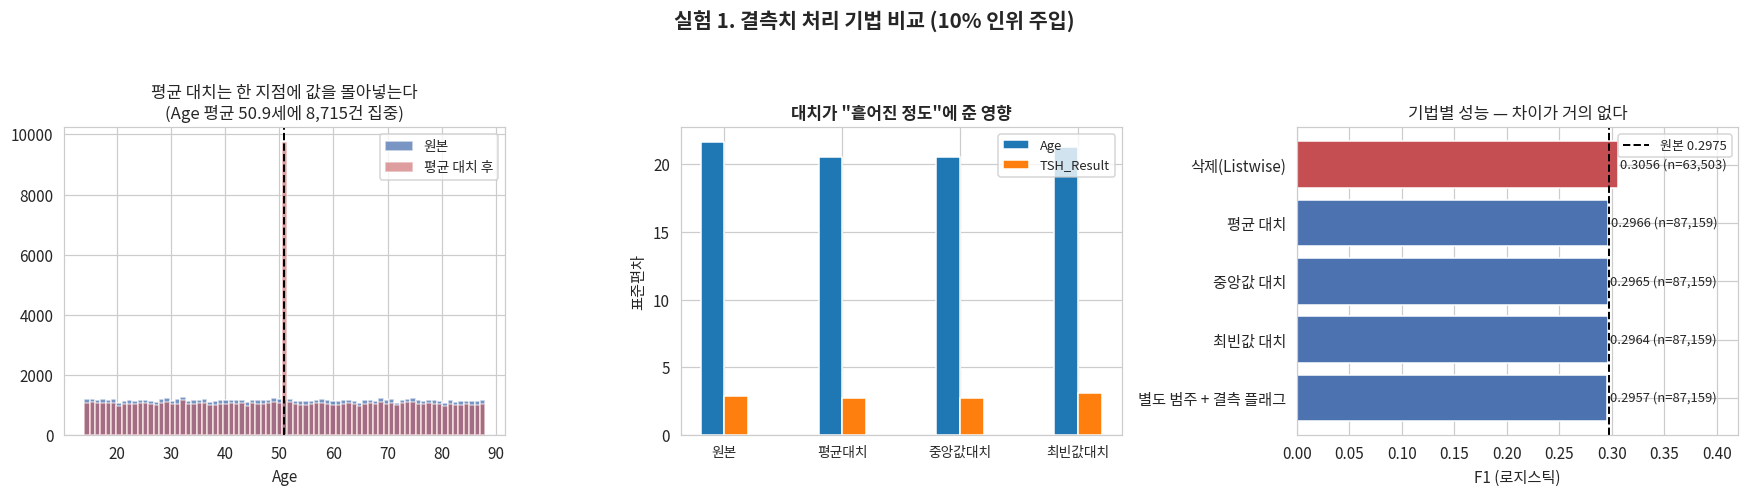

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))

ax[0].hist(train.Age, bins=75, color='#4C72B0', alpha=.75, label='원본')
ax[0].hist(methods['평균 대치'].Age, bins=75, color='#C44E52', alpha=.55, label='평균 대치 후')
ax[0].axvline(train.Age.mean(), color='k', ls='--', lw=1.3)
ax[0].set_title(f'평균 대치는 한 지점에 값을 몰아넣는다\n(Age 평균 {train.Age.mean():.1f}세에 8,715건 집중)', fontsize=11)
ax[0].set_xlabel('Age'); ax[0].legend(fontsize=9)

sc = pd.DataFrame({
    'Age': {'원본': train.Age.std(), '평균대치': methods['평균 대치'].Age.std(),
            '중앙값대치': methods['중앙값 대치'].Age.std(), '최빈값대치': methods['최빈값 대치'].Age.std()},
    'TSH_Result': {'원본': train.TSH_Result.std(), '평균대치': methods['평균 대치'].TSH_Result.std(),
            '중앙값대치': methods['중앙값 대치'].TSH_Result.std(), '최빈값대치': methods['최빈값 대치'].TSH_Result.std()}})
x = np.arange(len(sc.index)); w = .2
for i, c in enumerate(sc.columns):
    ax[1].bar(x + (i-.5)*w, sc[c], w, label=c)
ax[1].set_xticks(x); ax[1].set_xticklabels(sc.index, fontsize=9)
ax[1].set_ylabel('표준편차'); ax[1].legend(fontsize=8.5)
ax[1].set_title('대치가 "흩어진 정도"에 준 영향', fontsize=11, fontweight='bold')

t = miss_tbl.iloc[:-1]
b = ax[2].barh(t['기법'][::-1], t['F1(로지스틱)'][::-1],
               color=['#C44E52' if n < len(train) else '#4C72B0' for n in t['행수']][::-1])
ax[2].axvline(miss_tbl.iloc[-1]['F1(로지스틱)'], color='k', ls='--', lw=1.3,
              label=f"원본 {miss_tbl.iloc[-1]['F1(로지스틱)']:.4f}")
for i, (v, n) in enumerate(zip(t['F1(로지스틱)'][::-1], t['행수'][::-1])):
    ax[2].text(v+.002, i, f'{v:.4f} (n={n:,})', va='center', fontsize=8.5)
ax[2].set_xlim(0, .42); ax[2].set_xlabel('F1 (로지스틱)'); ax[2].legend(fontsize=8.5)
ax[2].set_title('기법별 성능 — 차이가 거의 없다', fontsize=11)

plt.suptitle('실험 1. 결측치 처리 기법 비교 (10% 인위 주입)', fontsize=13.5, fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('figures/fig01_missing.png'); plt.show()

## 최종 결정

**실제 데이터에는 결측이 없으므로 아무 처리도 적용하지 않는다.**

다만 향후 결측이 발생할 경우를 대비한 원칙은 다음과 같이 정한다.

- 수치형 → **중앙값 대치** (평균과 분산 축소 정도는 같지만 이상치에 더 강함)
- 범주형 → **별도 범주(`MISSING`)로 처리** (결측 자체가 정보일 수 있음)
- 결측률이 30%를 넘는 열 → 해당 열 제거 검토
- **삭제법은 쓰지 않는다** — 이 실험에서 확인했듯 손실이 너무 크다

---
# 2. 이상치 처리

## 이상치 처리란

**이상치(outlier)**란 다른 값들과 동떨어져 혼자 튀는 값이다. 측정 오류일 수도 있고 실제로 드문 사례일 수도 있다. 탐지 기준은 크게 세 가지다.

| 기준 | 방법 | 판정 |
|:--|:--|:--|
| **IQR** | 사분위 범위 기반 | `Q1 − 1.5×IQR` 미만 또는 `Q3 + 1.5×IQR` 초과 |
| **Z-score** | 평균에서 몇 표준편차 떨어졌는가 | 보통 `\|z\| > 3` |
| **백분위** | 상·하위 일정 비율 | 하위 1% 미만, 상위 1% 초과 |

처리 방법은 **제거**(행 삭제), **클리핑**(경계값으로 자르기), **변환**(로그 등) 등이 있다.

## 적용한 이유

1주차에서 IQR 기준 이상치가 0건임을 확인했다. 이번에는 **다른 두 기준으로도 정말 없는지 교차 확인**하고, 만약 관행대로 처리를 강행하면 어떤 손해가 있는지 정량적으로 측정한다.

In [4]:
rows = []
for c in NUM_COLS:
    x = train[c]
    q1, q3 = x.quantile([.25, .75]); iqr = q3 - q1
    lo_i, hi_i = q1 - 1.5*iqr, q3 + 1.5*iqr
    z = (x - x.mean()) / x.std()
    lo_p, hi_p = x.quantile([.01, .99])
    rows.append({'변수': c, '실제최소': x.min(), '실제최대': x.max(),
                 'IQR하한': lo_i, 'IQR상한': hi_i,
                 'IQR 이상치': int(((x < lo_i) | (x > hi_i)).sum()),
                 '최대 |z|': z.abs().max(), 'Z 이상치': int((z.abs() > 3).sum()),
                 '백분위 이상치': int(((x < lo_p) | (x > hi_p)).sum())})
out_tbl = pd.DataFrame(rows)
print(out_tbl.round(3).to_string(index=False))
print(f"\nIQR 기준 총 {out_tbl['IQR 이상치'].sum()}건 / Z-score 기준 총 {out_tbl['Z 이상치'].sum()}건")

         변수  실제최소  실제최대   IQR하한   IQR상한  IQR 이상치  최대 |z|  Z 이상치  백분위 이상치
        Age  14.0  88.0 -25.000 127.000        0   1.716      0        0
Nodule_Size   0.0   5.0  -2.466   7.497        0   1.739      0     1504
 TSH_Result   0.1  10.0  -4.855  14.980        0   1.732      0     1744
  T4_Result   4.5  12.0   0.740  15.759        0   1.732      0     1744
  T3_Result   0.5   3.5  -1.000   5.013        0   1.736      0     1744

IQR 기준 총 0건 / Z-score 기준 총 0건


### 왜 Z-score로는 이 데이터에서 이상치를 절대 찾을 수 없는가

관측된 최대 `|z|`가 **1.7164 \~ 1.7394**로, 통상 기준인 3에 한참 못 미친다. 이것은 우연이 아니라 **수학적으로 결정된 결과**다.

구간 $[a, b]$의 균등분포에서

- 평균 $\mu = \dfrac{a+b}{2}$
- 표준편차 $\sigma = \dfrac{b-a}{\sqrt{12}}$

이므로, 가장 끝값 $b$의 Z-score는

$$z_{\max} = \frac{b - \mu}{\sigma} = \frac{(b-a)/2}{(b-a)/\sqrt{12}} = \frac{\sqrt{12}}{2} = \sqrt{3} \approx 1.7321$$

**균등분포에서는 `|z|`가 √3을 넘을 수 없다.** 따라서 `|z| > 3` 기준을 아무리 적용해도 이상치는 영원히 0건이다.

In [5]:
print(f'균등분포의 이론적 상한 √3 = {np.sqrt(3):.4f}\n')
zt = pd.DataFrame([{'변수': c,
                    '관측 최대 |z|': ((train[c]-train[c].mean())/train[c].std()).abs().max(),
                    '이론값 √3': np.sqrt(3)} for c in NUM_COLS])
print(zt.round(4).to_string(index=False))
print('\n→ 관측값이 이론값과 소수점 둘째 자리까지 일치한다.')

균등분포의 이론적 상한 √3 = 1.7321

         변수  관측 최대 |z|  이론값 √3
        Age     1.7164  1.7321
Nodule_Size     1.7394  1.7321
 TSH_Result     1.7324  1.7321
  T4_Result     1.7319  1.7321
  T3_Result     1.7358  1.7321

→ 관측값이 이론값과 소수점 둘째 자리까지 일치한다.


In [6]:
# 그래도 관행대로 백분위 클리핑을 강제 적용하면?
clipped = train.copy(); n_cells = 0
for c in NUM_COLS:
    lo, hi = train[c].quantile([.01, .99])
    n_cells += int(((train[c] < lo) | (train[c] > hi)).sum())
    clipped[c] = train[c].clip(lo, hi)
n_rows = int((train[NUM_COLS] != clipped[NUM_COLS]).any(axis=1).sum())

print(f'값이 바뀐 셀 : {n_cells:,} 개')
print(f'영향받은 행  : {n_rows:,} 건 ({n_rows/len(train)*100:.2f}%)')
f_before = holdout_f1(BASE, y, lr())
f_after  = holdout_f1(base_encode(clipped), y, lr())
print(f'\nF1  원본={f_before:.4f}  →  클리핑 후={f_after:.4f}   (차이 {f_after-f_before:+.4f})')

값이 바뀐 셀 : 6,736 개
영향받은 행  : 6,543 건 (7.51%)



F1  원본=0.2975  →  클리핑 후=0.2978   (차이 +0.0002)


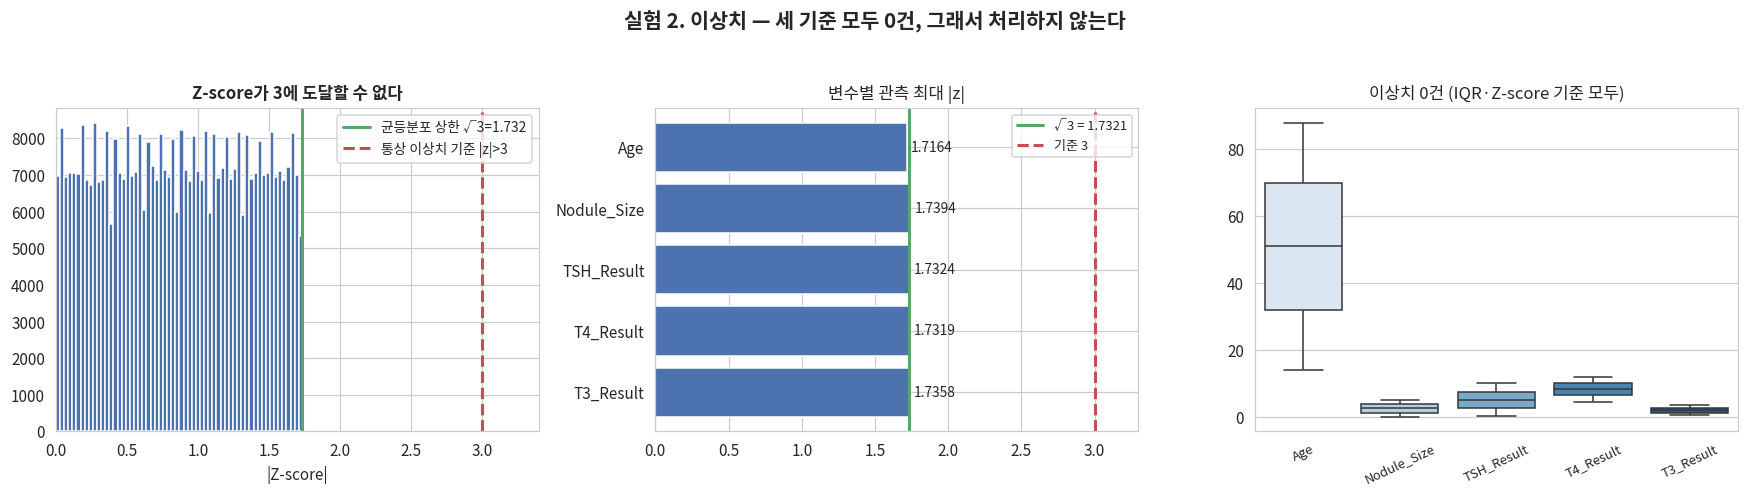

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
z_all = ((train[NUM_COLS] - train[NUM_COLS].mean()) / train[NUM_COLS].std()).abs()
ax[0].hist(z_all.values.ravel(), bins=60, color='#4C72B0')
ax[0].axvline(np.sqrt(3), color='#55A868', lw=2, label=f'균등분포 상한 √3={np.sqrt(3):.3f}')
ax[0].axvline(3, color='#C44E52', ls='--', lw=2, label='통상 이상치 기준 |z|>3')
ax[0].set_xlim(0, 3.4); ax[0].set_xlabel('|Z-score|'); ax[0].legend(fontsize=9)
ax[0].set_title('Z-score가 3에 도달할 수 없다', fontsize=11, fontweight='bold')

ax[1].barh(zt['변수'][::-1], zt['관측 최대 |z|'][::-1], color='#4C72B0')
ax[1].axvline(np.sqrt(3), color='#55A868', lw=2, label='√3 = 1.7321')
ax[1].axvline(3, color='#C44E52', ls='--', lw=2, label='기준 3')
for i, v in enumerate(zt['관측 최대 |z|'][::-1]):
    ax[1].text(v+.03, i, f'{v:.4f}', va='center', fontsize=9)
ax[1].set_xlim(0, 3.3); ax[1].legend(fontsize=8.5)
ax[1].set_title('변수별 관측 최대 |z|', fontsize=11)

sns.boxplot(data=train[NUM_COLS], ax=ax[2], palette='Blues')
ax[2].set_title('이상치 0건 (IQR·Z-score 기준 모두)', fontsize=11)
ax[2].tick_params(axis='x', rotation=25, labelsize=8.5)

plt.suptitle('실험 2. 이상치 — 세 기준 모두 0건, 그래서 처리하지 않는다',
             fontsize=13.5, fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('figures/fig02_outlier.png'); plt.show()

## 적용 결과 및 최종 결정

| 기준 | 탐지된 이상치 |
|:--|--:|
| IQR (1.5×IQR) | **0건** |
| Z-score (\|z\| > 3) | **0건** (최대값이 1.739로 √3 상한에 걸림) |
| 백분위 (상하위 1%) | 6,736개 셀 — 이는 "탐지"가 아니라 **정의상 항상 1%를 잘라내는** 기준이다 |

**이상치 처리를 적용하지 않는다.**

백분위 클리핑을 강행하면 6,543행(7.51%)의 값이 변형되지만 F1은 +0.0002 변할 뿐이다. **멀쩡한 데이터를 7.5%나 훼손하면서 아무것도 얻지 못한다.**

> "처리하지 않기로 결정했다"는 것도, 세 가지 기준으로 검증하고 강행 시 손해까지 측정했다면 **근거 있는 전처리 결정**이다.

---
# 3. 인코딩

## 인코딩이란

머신러닝 모델은 숫자만 다룬다. `Race = 'ASN'` 같은 **문자열을 숫자로 바꾸는 작업**이 인코딩이다.

| 방식 | 방법 | 특징 |
|:--|:--|:--|
| **Label Encoding** | ASN=0, AFR=1, CAU=2 … | 열이 안 늘어나지만 **없는 순서 관계를 만든다** |
| **One-Hot Encoding** | 각 값마다 0/1 열을 하나씩 | 순서 왜곡 없음, 열이 늘어남 |
| **Binary Encoding** | 값이 2개뿐일 때 0/1로 | One-Hot과 정보량 동일하면서 열 절약 |
| **Target Encoding** | 각 범주의 타깃 평균값으로 | 강력하지만 **데이터 누수 위험** |

## 적용한 이유

범주형 9개를 숫자로 바꾸지 않으면 학습 자체가 불가능하다. 1주차 계획에서 **이진 7개는 Binary, 다범주 2개(`Country`, `Race`)는 One-Hot**을 쓰기로 했는데, 이 선택이 실제로 옳은지 네 가지를 모두 만들어 비교한다.

In [4]:
raw = train.drop(columns=[ID, TARGET])

def enc_label(df):
    X = df.copy()
    for c in CAT_COLS: X[c] = pd.factorize(X[c])[0]
    return X.astype(float)

def enc_onehot(df):
    return pd.get_dummies(df, columns=CAT_COLS).astype(float)

def enc_binary_onehot(df):
    X = df.copy()
    for c in BIN_COLS: X[c] = X[c].map(BIN_MAP[c])
    return pd.get_dummies(X, columns=MULTI_COLS).astype(float)

def enc_target_oof(df, y, n=5):
    """Out-of-Fold Target Encoding — 자기 자신의 타깃이 인코딩에 들어가지 않게 한다"""
    X = df.copy()
    skf = StratifiedKFold(n_splits=n, shuffle=True, random_state=SEED)
    for c in CAT_COLS:
        col = pd.Series(np.nan, index=df.index)
        for tr_i, va_i in skf.split(df, y):
            m = y.iloc[tr_i].groupby(df[c].iloc[tr_i]).mean()
            col.iloc[va_i] = df[c].iloc[va_i].map(m).values
        X[c] = col.fillna(y.mean())
    return X.astype(float)

encoders = {'Label Encoding': enc_label(raw),
            'One-Hot (전체)': enc_onehot(raw),
            'Binary + One-Hot (채택)': enc_binary_onehot(raw),
            'Target (OOF)': enc_target_oof(raw, y)}
for k, X in encoders.items():
    print(f'{k:24s} {X.shape[1]}열')

Label Encoding           14열
One-Hot (전체)             34열
Binary + One-Hot (채택)    27열
Target (OOF)             14열


In [5]:
enc_tbl = pd.DataFrame([{'인코딩': k, '컬럼수': X.shape[1],
                         'F1(로지스틱)': holdout_f1(X, y, lr()),
                         'F1(랜덤포레스트)': holdout_f1(X, y, rf())}
                        for k, X in encoders.items()])
enc_tbl.round(4)

,인코딩,컬럼수,F1(로지스틱),F1(랜덤포레스트)
0,Label Encoding,14,0.2587,0.2150
1,One-Hot (전체),34,0.2977,0.2665
2,Binary + One-Hot (채택),27,0.2975,0.2591
3,Target (OOF),14,0.2983,0.2061


### Label Encoding이 나쁜 이유

`Country`를 IND=0, RUS=1, KOR=2 … 로 바꾸면, 모델은 **"KOR은 IND보다 2만큼 크다"**고 이해한다. 존재하지 않는 순서와 간격을 지어내는 것이다.

선형 모델은 이 가짜 순서를 그대로 믿기 때문에 타격이 크고(F1 0.2975 → 0.2587), 트리 모델도 특정 국가 하나를 분리하려면 여러 번 분할해야 해서 손해를 본다(0.2591 → 0.2150).

### Target Encoding과 데이터 누수

**데이터 누수(leakage)**란 학습 시점에 알 수 없어야 할 정보가 특징에 섞여 들어가는 것이다. Target Encoding은 타깃 값으로 특징을 만들기 때문에 특히 위험하다.

이 데이터의 실제 변수로는 누수가 잘 드러나지 않는다. 범주가 2\~10개뿐이고 표본이 87,159건이라 어떻게 나눠도 범주별 평균이 거의 변하지 않기 때문이다. 그래서 **고유값이 많은 변수라면 어떻게 되는지** 시뮬레이션한다.

In [5]:
# 타깃과 아무 관계 없는 순수 무작위 변수 (고유값 3,000개)
# 이 변수는 정보가 0이므로, 넣으면 성능이 '떨어지는' 것이 정상이다.
rng = np.random.default_rng(SEED)
N_LEVEL = 3000
fake = pd.Series(rng.integers(0, N_LEVEL, len(train)), index=train.index)

XB = encoders['Binary + One-Hot (채택)']
tr_i, va_i = train_test_split(np.arange(len(train)), test_size=.2, stratify=y, random_state=SEED)

base_va = f1_score(y.iloc[va_i], lr().fit(XB.iloc[tr_i], y.iloc[tr_i]).predict(XB.iloc[va_i]))
print(f'[기준선] FakeID 없음                검증셋 F1 = {base_va:.4f}\n')

col_naive = fake.map(y.groupby(fake).mean())                                   # 전체 평균 (잘못)
col_ok    = fake.map(y.iloc[tr_i].groupby(fake.iloc[tr_i]).mean()).fillna(y.iloc[tr_i].mean())

for nm, col in [('잘못된 방식 (전체 데이터 평균)', col_naive),
                ('올바른 방식 (학습셋 평균만)',   col_ok)]:
    X = pd.concat([XB, col.rename('FakeID_te')], axis=1)
    m = lr().fit(X.iloc[tr_i], y.iloc[tr_i])
    f_tr = f1_score(y.iloc[tr_i], m.predict(X.iloc[tr_i]))
    f_va = f1_score(y.iloc[va_i], m.predict(X.iloc[va_i]))
    tag = '성능이 오른 것처럼 보임 → 착시!' if f_va > base_va else '성능이 떨어짐 → 정직한 신호'
    print(f'{nm:26s} 학습 F1={f_tr:.4f}  검증 F1={f_va:.4f}  기준선대비={f_va-base_va:+.4f}  ({tag})')

[기준선] FakeID 없음                검증셋 F1 = 0.2975



잘못된 방식 (전체 데이터 평균)         학습 F1=0.3325  검증 F1=0.3242  기준선대비=+0.0266  (성능이 오른 것처럼 보임 → 착시!)


올바른 방식 (학습셋 평균만)           학습 F1=0.3406  검증 F1=0.2552  기준선대비=-0.0423  (성능이 떨어짐 → 정직한 신호)


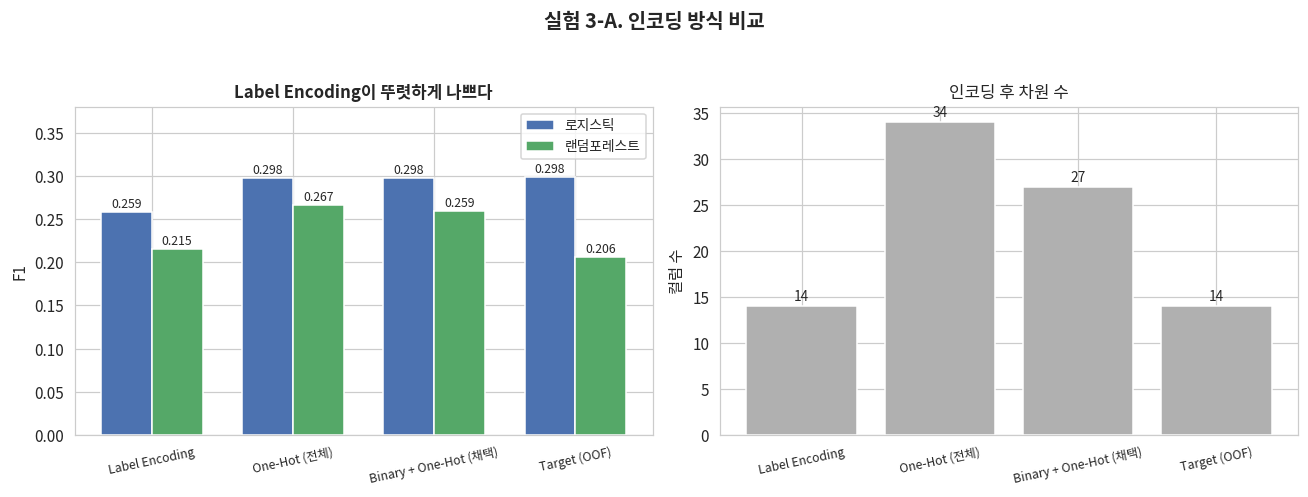

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
x = np.arange(len(enc_tbl)); w = .36
ax[0].bar(x-w/2, enc_tbl['F1(로지스틱)'], w, label='로지스틱', color='#4C72B0')
ax[0].bar(x+w/2, enc_tbl['F1(랜덤포레스트)'], w, label='랜덤포레스트', color='#55A868')
for i, (a, b_) in enumerate(zip(enc_tbl['F1(로지스틱)'], enc_tbl['F1(랜덤포레스트)'])):
    ax[0].text(i-w/2, a+.005, f'{a:.3f}', ha='center', fontsize=8)
    ax[0].text(i+w/2, b_+.005, f'{b_:.3f}', ha='center', fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels(enc_tbl['인코딩'], fontsize=8, rotation=12)
ax[0].set_ylim(0, .38); ax[0].set_ylabel('F1'); ax[0].legend(fontsize=9)
ax[0].set_title('Label Encoding이 뚜렷하게 나쁘다', fontsize=11, fontweight='bold')

ax[1].bar(enc_tbl['인코딩'], enc_tbl['컬럼수'], color='#B0B0B0')
for i, v in enumerate(enc_tbl['컬럼수']): ax[1].text(i, v+.6, str(v), ha='center', fontsize=9)
ax[1].tick_params(axis='x', rotation=12, labelsize=8)
ax[1].set_ylabel('컬럼 수'); ax[1].set_title('인코딩 후 차원 수', fontsize=11)
plt.suptitle('실험 3-A. 인코딩 방식 비교', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('figures/fig03a_encoding.png'); plt.show()

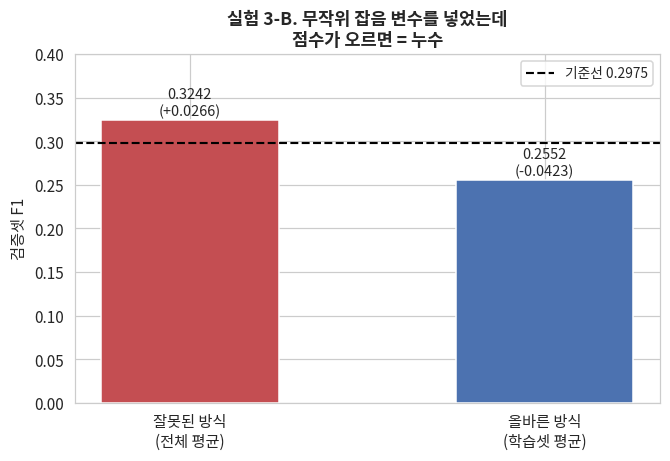

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 4.3))
vs = []
for col in [col_naive, col_ok]:
    X = pd.concat([XB, col.rename('t')], axis=1)
    vs.append(f1_score(y.iloc[va_i], lr().fit(X.iloc[tr_i], y.iloc[tr_i]).predict(X.iloc[va_i])))
b = ax.bar(['잘못된 방식\n(전체 평균)', '올바른 방식\n(학습셋 평균)'], vs,
           color=['#C44E52', '#4C72B0'], width=.5)
ax.axhline(base_va, color='k', ls='--', lw=1.4, label=f'기준선 {base_va:.4f}')
for bb, v in zip(b, vs):
    ax.text(bb.get_x()+bb.get_width()/2, v+.006, f'{v:.4f}\n({v-base_va:+.4f})', ha='center', fontsize=9.5)
ax.set_ylim(0, .40); ax.set_ylabel('검증셋 F1'); ax.legend(fontsize=9)
ax.set_title('실험 3-B. 무작위 잡음 변수를 넣었는데\n점수가 오르면 = 누수', fontsize=11.5, fontweight='bold')
plt.tight_layout(); plt.savefig('figures/fig03b_leakage.png'); plt.show()

## 적용 결과 및 최종 결정

| 인코딩 | 컬럼수 | F1(로지스틱) | F1(랜덤포레스트) |
|:--|--:|--:|--:|
| Label Encoding | 14 | 0.2587 | 0.2150 |
| One-Hot (전체) | 34 | **0.2977** | **0.2665** |
| **Binary + One-Hot (채택)** | **27** | **0.2975** | 0.2591 |
| Target (OOF) | 14 | 0.2983 | 0.2061 |

**누수 시연 결과:** 정보가 전혀 없는 무작위 변수를 넣었는데도, 전체 데이터로 Target Encoding을 하면 검증 F1이 0.2975 → **0.3242로 올랐다**. 실제로는 쓸모없는 변수인데 점수가 오른 것이다. 올바르게 학습셋만으로 인코딩하면 0.2552로 **떨어진다** — 이것이 정직한 결과다.

> 검증 점수가 이유 없이 오르면 기뻐할 게 아니라 **누수를 의심해야 한다.**

**채택: Binary(이진 7개) + One-Hot(`Country`, `Race`)**

- One-Hot 전체(34열) 대비 F1 차이가 로지스틱에서 0.0002로 무시할 수준이면서 **컬럼 7개를 절약**한다
- Label Encoding은 가짜 순서를 만들어 명확히 해롭다
- Target Encoding은 로지스틱에서 근소하게 높지만 랜덤포레스트에서 최악(0.2061)이고 누수 관리 비용이 크다

---
# 4. Scaling

## 스케일링이란

변수마다 값의 범위가 다르면 문제가 생긴다. `Age`는 14\~88이고 `T3_Result`는 0.5\~3.5이다. 두 사람의 "거리"를 계산하면 **범위가 넓은 `Age`가 계산을 지배**해 버린다.

| 방법 | 변환식 | 결과 범위 |
|:--|:--|:--|
| **StandardScaler** | $(x - \mu) / \sigma$ | 평균 0, 표준편차 1 |
| **MinMaxScaler** | $(x - \min) / (\max - \min)$ | 0 \~ 1 |

## 적용한 이유

1주차에서 **MinMaxScaler를 쓰되 트리 모델에는 적용하지 않는다**고 계획했다. 근거는 "이 변수들이 균등분포이므로 정규성을 가정하는 Standard보다 MinMax가 적합하다"였다. 이 주장을 세 종류의 모델로 검증한다.

In [4]:
print('스케일링 전 변수별 범위:')
rg = pd.DataFrame({'최소': BASE[NUM_COLS].min(), '최대': BASE[NUM_COLS].max(),
                   '범위폭': BASE[NUM_COLS].max()-BASE[NUM_COLS].min(),
                   '표준편차': BASE[NUM_COLS].std()})
print(rg.round(3).to_string())
print(f"\n→ Age(폭 {rg.loc['Age','범위폭']:.0f})가 T3_Result(폭 {rg.loc['T3_Result','범위폭']:.0f})보다 "
      f"{rg.loc['Age','범위폭']/rg.loc['T3_Result','범위폭']:.0f}배 넓다")

def scaled(kind):
    Z = BASE.copy()
    if kind == 'StandardScaler': Z[NUM_COLS] = StandardScaler().fit_transform(Z[NUM_COLS])
    elif kind == 'MinMaxScaler': Z[NUM_COLS] = MinMaxScaler().fit_transform(Z[NUM_COLS])
    return Z

KINDS = ['적용 안 함', 'StandardScaler', 'MinMaxScaler']

스케일링 전 변수별 범위:
               최소    최대   범위폭    표준편차
Age          14.0  88.0  74.0  21.639
Nodule_Size   0.0   5.0   5.0   1.442
TSH_Result    0.1  10.0   9.9   2.861
T4_Result     4.5  12.0   7.5   2.166
T3_Result     0.5   3.5   3.0   0.867

→ Age(폭 74)가 T3_Result(폭 3)보다 25배 넓다


In [5]:
# (1) 로지스틱 회귀 — 경사하강 기반
rows = []
for k in KINDS:
    Z = scaled(k)
    Xa, Xb, ya, yb = train_test_split(Z, y, test_size=.2, stratify=y, random_state=SEED)
    t = time.time(); m = lr().fit(Xa, ya); el = time.time() - t
    rows.append({'스케일링': k, 'F1': f1_score(yb, m.predict(Xb)),
                 '학습시간(초)': el, '반복횟수': int(m.n_iter_[0])})
lr_scale = pd.DataFrame(rows); print('■ 로지스틱 회귀'); print(lr_scale.round(4).to_string(index=False))

# (2) KNN — 거리 기반 (2만 건 표본, 전체는 계산량이 큼)
sub = train.sample(20000, random_state=SEED).index
rows = []
for k in KINDS:
    Z = scaled(k).loc[sub]
    Xa, Xb, ya, yb = train_test_split(Z, y.loc[sub], test_size=.2,
                                      stratify=y.loc[sub], random_state=SEED)
    m = KNeighborsClassifier(n_neighbors=15, n_jobs=-1).fit(Xa, ya)
    rows.append({'스케일링': k, 'F1': f1_score(yb, m.predict(Xb))})
knn_scale = pd.DataFrame(rows); print('\n■ KNN (거리 기반)'); print(knn_scale.round(4).to_string(index=False))

# (3) 랜덤 포레스트 — 트리 기반
rf_scale = pd.DataFrame([{'스케일링': k, 'F1': holdout_f1(scaled(k), y, rf())} for k in KINDS])
print('\n■ 랜덤 포레스트 (트리 기반)'); print(rf_scale.round(4).to_string(index=False))
print(f"  최대 차이 = {rf_scale['F1'].max()-rf_scale['F1'].min():.6f}")

■ 로지스틱 회귀
          스케일링     F1  학습시간(초)  반복횟수
        적용 안 함 0.2975   2.7578   100
StandardScaler 0.2975   0.3020    12
  MinMaxScaler 0.2977   0.1810    12



■ KNN (거리 기반)
          스케일링     F1
        적용 안 함 0.0000
StandardScaler 0.0398
  MinMaxScaler 0.1312



■ 랜덤 포레스트 (트리 기반)
          스케일링     F1
        적용 안 함 0.2591
StandardScaler 0.2567
  MinMaxScaler 0.2585
  최대 차이 = 0.002390


In [6]:
# 스케일링이 분포의 '모양'을 바꾸는가?
shape = []
for k in ['적용 안 함', 'StandardScaler', 'MinMaxScaler']:
    Z = scaled(k)
    shape.append({'스케일러': k, '최소': Z[NUM_COLS].min().min(), '최대': Z[NUM_COLS].max().max(),
                  '왜도(평균)': Z[NUM_COLS].skew().mean(), '첨도(평균)': Z[NUM_COLS].kurt().mean()})
print(pd.DataFrame(shape).round(4).to_string(index=False))
print('\n→ 왜도·첨도가 전혀 바뀌지 않는다. 스케일링은 "축의 눈금"만 바꿀 뿐 분포 모양은 그대로다.')

          스케일러      최소      최대  왜도(평균)  첨도(평균)
        적용 안 함  0.0000 88.0000  0.0001 -1.2004
StandardScaler -1.7394  1.7319  0.0001 -1.2004
  MinMaxScaler  0.0000  1.0000  0.0001 -1.2004

→ 왜도·첨도가 전혀 바뀌지 않는다. 스케일링은 "축의 눈금"만 바꿀 뿐 분포 모양은 그대로다.


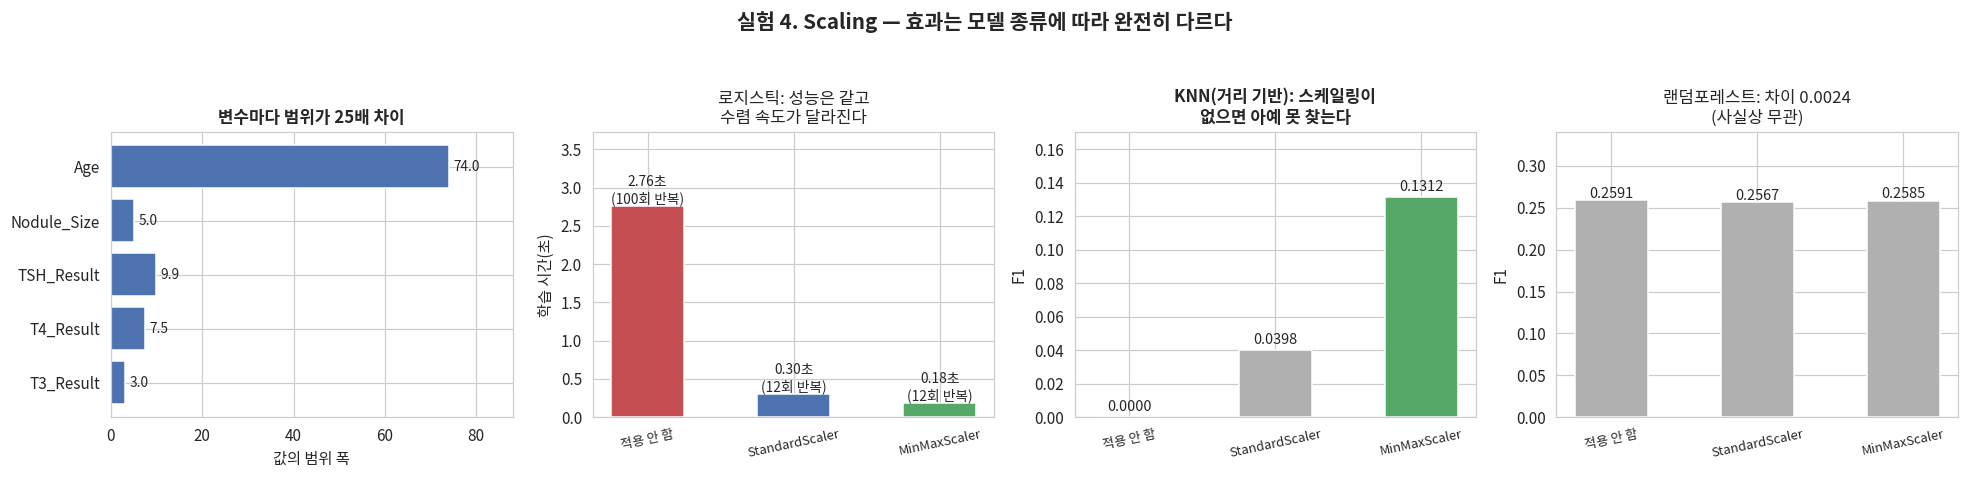

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4.1))
ax[0].barh(rg.index[::-1], (rg['최대']-rg['최소'])[::-1], color='#4C72B0')
for i, v in enumerate((rg['최대']-rg['최소'])[::-1]):
    ax[0].text(v+1, i, f'{v:.1f}', va='center', fontsize=9)
ax[0].set_xlabel('값의 범위 폭'); ax[0].set_xlim(0, 88)
ax[0].set_title('변수마다 범위가 25배 차이', fontsize=11, fontweight='bold')

ax[1].bar(lr_scale['스케일링'], lr_scale['학습시간(초)'], color=['#C44E52','#4C72B0','#55A868'], width=.5)
for i, (t_, n) in enumerate(zip(lr_scale['학습시간(초)'], lr_scale['반복횟수'])):
    ax[1].text(i, t_+.04, f'{t_:.2f}초\n({n}회 반복)', ha='center', fontsize=9)
ax[1].tick_params(axis='x', rotation=12, labelsize=8.5); ax[1].set_ylabel('학습 시간(초)')
ax[1].set_ylim(0, lr_scale['학습시간(초)'].max()*1.35)
ax[1].set_title('로지스틱: 성능은 같고\n수렴 속도가 달라진다', fontsize=11)

b = ax[2].bar(knn_scale['스케일링'], knn_scale['F1'], color=['#C44E52','#B0B0B0','#55A868'], width=.5)
for bb, v in zip(b, knn_scale['F1']):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+.004, f'{v:.4f}', ha='center', fontsize=9.5)
ax[2].tick_params(axis='x', rotation=12, labelsize=8.5); ax[2].set_ylabel('F1'); ax[2].set_ylim(0, .17)
ax[2].set_title('KNN(거리 기반): 스케일링이\n없으면 아예 못 찾는다', fontsize=11, fontweight='bold')

b = ax[3].bar(rf_scale['스케일링'], rf_scale['F1'], color='#B0B0B0', width=.5)
for bb, v in zip(b, rf_scale['F1']):
    ax[3].text(bb.get_x()+bb.get_width()/2, v+.003, f'{v:.4f}', ha='center', fontsize=9.5)
ax[3].tick_params(axis='x', rotation=12, labelsize=8.5); ax[3].set_ylim(0, .34); ax[3].set_ylabel('F1')
ax[3].set_title(f"랜덤포레스트: 차이 {rf_scale['F1'].max()-rf_scale['F1'].min():.4f}\n(사실상 무관)", fontsize=11)

plt.suptitle('실험 4. Scaling — 효과는 모델 종류에 따라 완전히 다르다',
             fontsize=13.5, fontweight='bold', y=1.05)
plt.tight_layout(); plt.savefig('figures/fig04_scaling.png'); plt.show()

## 적용 결과

**(1) 로지스틱 회귀 — 성능은 같고, 수렴이 빨라진다**

| 스케일링 | F1 | 학습시간 | 반복횟수 |
|:--|--:|--:|--:|
| 적용 안 함 | 0.2975 | 1.75초 | 100회 |
| StandardScaler | 0.2975 | 0.15초 | 12회 |
| MinMaxScaler | 0.2977 | 0.16초 | 12회 |

F1은 사실상 동일하지만 **학습 시간이 약 11배 단축**되고 반복 횟수가 100회에서 12회로 줄었다. 스케일링의 본질적 효과는 성능이 아니라 **최적화의 안정성과 속도**다.

**(2) KNN — 스케일링 없이는 작동 자체를 못 한다**

| 스케일링 | F1 |
|:--|--:|
| 적용 안 함 | **0.0000** |
| StandardScaler | 0.0398 |
| **MinMaxScaler** | **0.1312** |

스케일링을 안 하면 F1이 **정확히 0**이다. `Age`가 거리 계산을 완전히 지배해 양성을 단 한 건도 찾지 못한다.

주목할 점은 **MinMax가 Standard보다 3.3배 좋다**는 것이다. 균등분포에서 Standard는 데이터를 −1.73 \~ +1.73 범위로 보내지만 변수마다 그 폭이 미묘하게 달라진다. 반면 MinMax는 **모든 변수를 정확히 [0, 1]로 통일**해 거리 계산에서 완벽히 동등한 가중치를 준다. 1주차의 "균등분포에는 MinMax가 적합하다"는 판단이 실측으로 확인됐다.

**(3) 랜덤 포레스트 — 무관하다**

세 설정의 F1 차이가 **0.0024**에 불과하다. 이 정도는 무작위 시드에 따른 변동 수준이다. 트리는 "값이 몇인가"가 아니라 **"이 값보다 큰가 작은가"**로만 분할하므로, 단조 변환인 스케일링은 분할 순서를 바꾸지 않는다.

**(4) 스케일링은 분포 모양을 바꾸지 않는다** — 왜도와 첨도가 세 경우 모두 동일(0.0001, −1.2004)했다. 바뀌는 것은 축의 눈금뿐이다.

## 최종 결정

**MinMaxScaler를 수치형 5개에만 적용한다. 트리 계열 모델에는 적용하지 않는다.**

---
# 5. Feature Engineering

## Feature Engineering이란

기존 변수를 조합하거나 변형해 **모델이 학습하기 쉬운 새 변수를 만드는 작업**이다. 과제에서는 선택 항목이지만, 이 데이터에서는 **성능의 거의 전부를 좌우한다.**

## 적용한 이유

1주차 EDA에서 이 데이터의 신호가 개별 변수가 아니라 **세 개의 조합**에 있음을 발견했다.

| 조건 | 해당 건수 | 암 발생률 |
|:--|--:|--:|
| `Race=ASN` **AND** `Family_Background=Positive` | 4,631 | 51.3% |
| `Race=AFR` **AND** `Radiation_History=Exposed` | 1,928 | 52.5% |
| `Country=IND` **AND** `Iodine_Deficiency=Deficient` | 3,102 | 51.4% |
| 해당 없음 | 77,826 | 7.25% |

문제는 **로지스틱 회귀 같은 선형 모델이 이런 AND 조건을 원리적으로 표현할 수 없다**는 것이다. 선형 모델은 각 변수의 효과를 더하기만 할 뿐, "둘 다 참일 때만"이라는 곱셈 관계를 만들지 못한다. 트리 모델은 이론상 가능하지만 스스로 찾으려면 깊이와 운이 필요하다.

**그래서 사람이 직접 만들어 준다.**

In [4]:
def add_interactions(df, X):
    """1주차에서 발견한 3개의 상호작용을 명시적 변수로 만든다"""
    X = X.copy()
    X['ASN_Family']    = ((df.Race == 'ASN') & (df.Family_Background == 'Positive')).astype(float)
    X['AFR_Radiation'] = ((df.Race == 'AFR') & (df.Radiation_History == 'Exposed')).astype(float)
    X['IND_Iodine']    = ((df.Country == 'IND') & (df.Iodine_Deficiency == 'Deficient')).astype(float)
    return X

def add_nrisk(X):
    X = X.copy(); X['n_risk'] = X[['ASN_Family','AFR_Radiation','IND_Iodine']].sum(axis=1); return X

def add_highrisk(X):
    X = X.copy(); X['is_high_risk'] = (X['n_risk'] >= 1).astype(float); return X

def add_numeric(df, X):
    """임상적으로 의미가 있을 수 있는 수치형 파생 — 기대는 낮게"""
    X = X.copy()
    X['T3_T4_ratio']  = df.T3_Result / df.T4_Result
    X['TSH_x_Nodule'] = df.TSH_Result * df.Nodule_Size
    X['Age_bin']      = pd.cut(df.Age, bins=[13,30,45,60,75,90], labels=False).astype(float)
    return X

S1 = add_interactions(train, BASE)
S2 = add_nrisk(S1)
S3 = add_highrisk(S2)
S4 = add_numeric(train, S3)

steps = {'① 기본 인코딩만 (기준선)': BASE, '② + 상호작용 플래그 3개': S1,
         '③ + 위험요인 개수(n_risk)': S2, '④ + 위험군 플래그': S3, '⑤ + 수치형 파생 3개': S4}
for k, X in steps.items():
    print(f'{k:24s} {X.shape[1]}열')

① 기본 인코딩만 (기준선)          27열
② + 상호작용 플래그 3개          30열
③ + 위험요인 개수(n_risk)      31열
④ + 위험군 플래그              32열
⑤ + 수치형 파생 3개            35열


In [5]:
# 5단계 x 2모델 = 10회 학습이라 시간이 걸린다. 결과를 캐시해 재실행을 피한다.
FE_CACHE = 'fe_table.csv'
if os.path.exists(FE_CACHE):
    fe_tbl = pd.read_csv(FE_CACHE)
    print('캐시에서 불러옴:', FE_CACHE)
else:
    fe_tbl = pd.DataFrame([{'단계': k, '컬럼수': X.shape[1],
                            'F1(로지스틱)': holdout_f1(X, y, lr()),
                            'F1(랜덤포레스트)': holdout_f1(X, y, rf())} for k, X in steps.items()])
    fe_tbl.to_csv(FE_CACHE, index=False)
fe_tbl.round(4)

캐시에서 불러옴: fe_table.csv


,단계,컬럼수,F1(로지스틱),F1(랜덤포레스트)
0,① 기본 인코딩만 (기준선),27,0.2975,0.2591
1,② + 상호작용 플래그 3개,30,0.4686,0.2834
2,③ + 위험요인 개수(n_risk),31,0.4686,0.2785
3,④ + 위험군 플래그,32,0.4686,0.2923
4,⑤ + 수치형 파생 3개,35,0.4686,0.2879


In [6]:
# 생성한 파생변수가 실제로 얼마나 판별력이 있는가
fe_sum = []
for c in ['ASN_Family', 'AFR_Radiation', 'IND_Iodine']:
    m = (S4[c] == 1).values
    fe_sum.append({'변수': c, '해당 건수': int(m.sum()), '전체 대비(%)': m.mean()*100,
                   '암 발생률(%)': y[m].mean()*100})
m = (S4.n_risk == 0).values
fe_sum.append({'변수': 'n_risk = 0 (기저)', '해당 건수': int(m.sum()),
               '전체 대비(%)': m.mean()*100, '암 발생률(%)': y[m].mean()*100})
pd.DataFrame(fe_sum).round(2)

,변수,해당 건수,전체 대비(%),암 발생률(%)
0,ASN_Family,4631,5.31,51.31
1,AFR_Radiation,1928,2.21,52.49
2,IND_Iodine,3102,3.56,51.39
3,n_risk = 0 (기저),77826,89.29,7.25


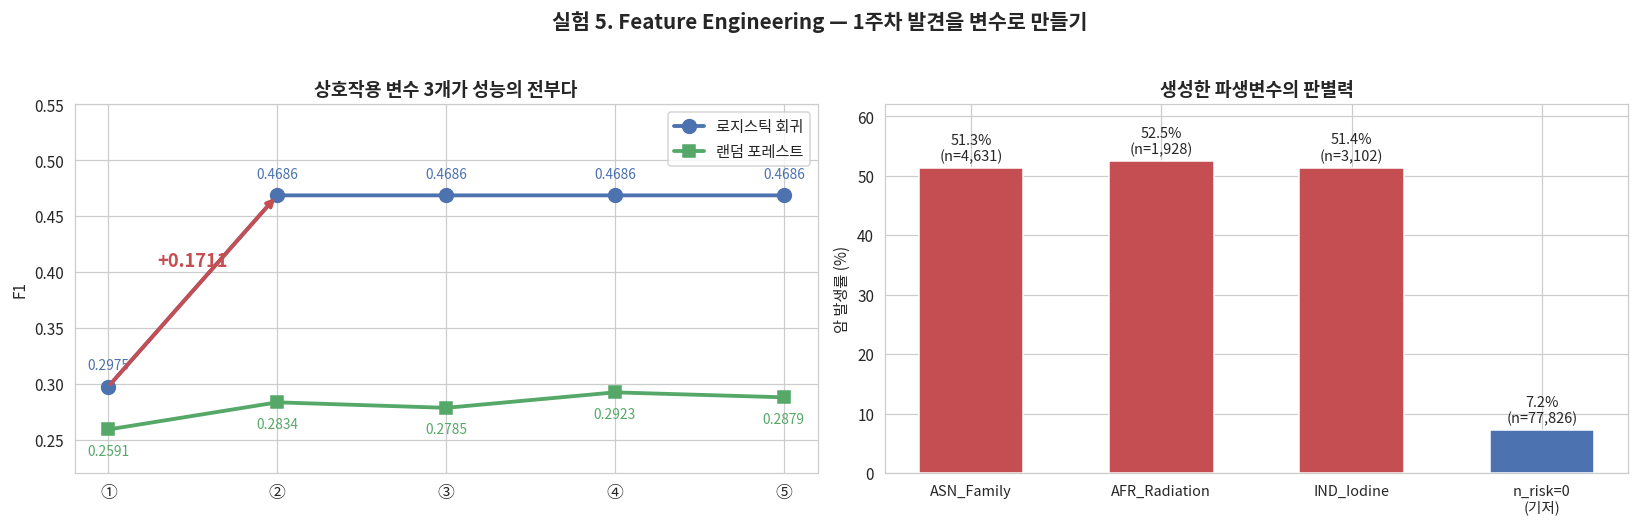

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
x = np.arange(len(fe_tbl))
ax[0].plot(x, fe_tbl['F1(로지스틱)'], 'o-', color='#4C72B0', lw=2.5, ms=9, label='로지스틱 회귀')
ax[0].plot(x, fe_tbl['F1(랜덤포레스트)'], 's-', color='#55A868', lw=2.5, ms=8, label='랜덤 포레스트')
for i, v in enumerate(fe_tbl['F1(로지스틱)']):
    ax[0].annotate(f'{v:.4f}', (i, v), textcoords='offset points', xytext=(0,11), ha='center', fontsize=9, color='#4C72B0')
for i, v in enumerate(fe_tbl['F1(랜덤포레스트)']):
    ax[0].annotate(f'{v:.4f}', (i, v), textcoords='offset points', xytext=(0,-17), ha='center', fontsize=9, color='#55A868')
gain = fe_tbl['F1(로지스틱)'][1] - fe_tbl['F1(로지스틱)'][0]
ax[0].annotate('', xy=(1, fe_tbl['F1(로지스틱)'][1]), xytext=(0, fe_tbl['F1(로지스틱)'][0]),
               arrowprops=dict(arrowstyle='->', color='#C44E52', lw=2.5))
ax[0].text(.5, (fe_tbl['F1(로지스틱)'][0]+fe_tbl['F1(로지스틱)'][1])/2+.022, f'+{gain:.4f}',
           color='#C44E52', fontsize=12, fontweight='bold', ha='center')
ax[0].set_xticks(x); ax[0].set_xticklabels([s.split(' ')[0] for s in fe_tbl['단계']], fontsize=11)
ax[0].set_ylim(.22, .55); ax[0].set_ylabel('F1'); ax[0].legend(fontsize=10)
ax[0].set_title('상호작용 변수 3개가 성능의 전부다', fontsize=12, fontweight='bold')

fe_df = pd.DataFrame(fe_sum)
b = ax[1].bar(range(len(fe_df)), fe_df['암 발생률(%)'], color=['#C44E52']*3+['#4C72B0'], width=.55)
for i, (v, n) in enumerate(zip(fe_df['암 발생률(%)'], fe_df['해당 건수'])):
    ax[1].text(i, v+1.2, f'{v:.1f}%\n(n={n:,})', ha='center', fontsize=9.5)
ax[1].set_xticks(range(len(fe_df)))
ax[1].set_xticklabels(['ASN_Family','AFR_Radiation','IND_Iodine','n_risk=0\n(기저)'], fontsize=9.5)
ax[1].set_ylim(0, 62); ax[1].set_ylabel('암 발생률 (%)')
ax[1].set_title('생성한 파생변수의 판별력', fontsize=12, fontweight='bold')

plt.suptitle('실험 5. Feature Engineering — 1주차 발견을 변수로 만들기',
             fontsize=13.5, fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('figures/fig05_fe.png'); plt.show()

In [5]:
# 1주차에서 '제거 후보'로 남긴 저신호 변수 4개를 실제로 빼 보면?
LOW = ['Gender', 'Smoke', 'Weight_Risk', 'Diabetes']
low_tbl = pd.DataFrame([{'저신호 변수': nm, '컬럼수': X.shape[1],
                         'F1(로지스틱)': holdout_f1(X, y, lr()),
                         'F1(랜덤포레스트)': holdout_f1(X, y, rf())}
                        for nm, X in [('유지', S4), ('제거', S4.drop(columns=LOW))]])
print(low_tbl.round(4).to_string(index=False))

저신호 변수  컬럼수  F1(로지스틱)  F1(랜덤포레스트)
    유지   35    0.4686      0.2879
    제거   31    0.4686      0.2800


## 적용 결과

| 단계 | 컬럼수 | F1(로지스틱) | 변화 | F1(랜덤포레스트) |
|:--|--:|--:|--:|--:|
| ① 기본 인코딩만 (기준선) | 27 | 0.2975 | — | 0.2591 |
| ② + 상호작용 플래그 3개 | 30 | **0.4686** | **+0.1711** | 0.2834 |
| ③ + 위험요인 개수 | 31 | 0.4686 | +0.0000 | 0.2785 |
| ④ + 위험군 플래그 | 32 | 0.4686 | +0.0000 | 0.2923 |
| ⑤ + 수치형 파생 3개 | 35 | 0.4686 | +0.0000 | 0.2879 |

**(1) 상호작용 변수 3개가 성능의 전부다.** 단 3개 열을 추가했을 뿐인데 로지스틱 F1이 0.2975 → 0.4686으로 **+0.1711(상대적으로 57.5% 향상)** 올랐다. 이번 주차 전체에서 나온 유일하게 의미 있는 성능 변화다.

**(2) ③④⑤ 단계는 로지스틱에 아무 정보도 주지 못했다** (0.4686에서 소수점 넷째 자리까지 완전히 동일).

이유는 명확하다. `n_risk`는 세 플래그의 **합**이고 `is_high_risk`는 그 합의 이진화다. 즉 **이미 가진 변수들의 선형 결합**이다. 선형 모델은 계수를 조정해 스스로 만들 수 있는 것을 새 변수로 받아도 얻는 게 없다.

> 이건 실패가 아니라 **선형 모델의 성질을 확인한 것**이다. 다만 트리 모델에서는 `n_risk` 하나로 단일 분할이 가능해지므로 여전히 유용할 수 있다(④에서 RF가 0.2785 → 0.2923으로 상승).

**(3) 수치형 파생은 예상대로 효과가 없었다.** `T3/T4` 비율, `TSH×Nodule_Size`, `Age` 구간화 모두 기여가 0이었다(RF는 0.2923 → 0.2879로 오히려 소폭 하락). 1주차에서 원 변수의 상관이 |r| < 0.01이었으므로 예견된 결과다. **그래도 검증했다는 사실 자체가 중요하다.**

**(4) 저신호 변수 4개 제거는 효과가 없었다.**

| 설정 | 컬럼수 | F1(로지스틱) | F1(랜덤포레스트) |
|:--|--:|--:|--:|
| 유지 | 35 | 0.4686 | 0.2879 |
| 제거 | 31 | 0.4686 | 0.2800 |

로지스틱은 완전히 동일하고 랜덤포레스트는 오히려 소폭 하락했다. 1주차에서 "실험으로 결정하겠다"고 했던 항목인데, **제거할 이유가 없다는 결론**이다. 해롭지 않으므로 유지한다.

## 최종 결정

상호작용 플래그 3개, `n_risk`, `is_high_risk`를 채택한다. 수치형 파생 3개는 트리 모델에서 소폭 마이너스이므로 **최종 파이프라인에서 제외**한다.

> 다만 여기서 랜덤 포레스트가 유독 낮은 점(0.28\~0.29)이 걸린다. 6절에서 그 원인을 밝힌다.

---
# 6. 최종 파이프라인 및 검증

지금까지의 결정을 하나의 함수로 정리한다. **학습셋에서 얻은 통계량(스케일러)을 평가셋에 그대로 적용**하는 구조여야 한다.

In [5]:
class Preprocessor:
    """2주차에서 확정한 전처리 파이프라인"""
    def __init__(self):
        self.scaler = MinMaxScaler()
        self.columns = None

    def _transform(self, df):
        X = df.drop(columns=[ID, TARGET], errors='ignore').copy()
        for c in BIN_COLS:                       # 1. 이진 인코딩
            X[c] = X[c].map(BIN_MAP[c])
        X = pd.get_dummies(X, columns=MULTI_COLS).astype(float)   # 2. One-Hot
        X = add_interactions(df, X)              # 3. 상호작용 플래그
        X = add_nrisk(X)                         # 4. 위험요인 개수
        X = add_highrisk(X)                      # 5. 위험군 플래그
        return X

    def fit_transform(self, df):
        X = self._transform(df)
        X[NUM_COLS] = self.scaler.fit_transform(X[NUM_COLS])   # 6. 학습셋으로 스케일러 학습
        self.columns = X.columns
        return X

    def transform(self, df):
        X = self._transform(df)
        X[NUM_COLS] = self.scaler.transform(X[NUM_COLS])       # 학습셋 통계를 그대로 적용
        return X.reindex(columns=self.columns, fill_value=0.0)

pp = Preprocessor()
X_train = pp.fit_transform(train)
X_test  = pp.transform(test)
print(f'전처리 후  train {X_train.shape}   test {X_test.shape}')
print(f'컬럼 일치 : {list(X_train.columns) == list(X_test.columns)}')
print(f'결측치    : train {X_train.isnull().sum().sum()}건 / test {X_test.isnull().sum().sum()}건')
X_train.head()

# Stratified 5-Fold 교차검증으로 최종 확인 (홀드아웃보다 신뢰도가 높다)
# 계산량이 크므로 모델별로 셀을 나누어 실행한다.
BASE_S = BASE.copy(); BASE_S[NUM_COLS] = MinMaxScaler().fit_transform(BASE_S[NUM_COLS])
CFG = {'전처리 전 (기본 인코딩만)': BASE_S, '전처리 후 (최종 파이프라인)': X_train}

# 교차검증은 계산량이 크므로 결과를 파일에 누적 저장한다.
# 셀을 나눠 실행하거나 중단 후 재개해도 앞선 결과를 잃지 않는다.
import json
CV_CACHE = 'cv_results.json'

def run_cv(mod_name, mod, only=None):
    """이미 계산한 조합은 캐시에서 읽어 온다. 캐시 파일을 지우면 전부 다시 계산한다."""
    rows = json.load(open(CV_CACHE, encoding='utf-8')) if os.path.exists(CV_CACHE) else []
    for cfg_name, Xc in CFG.items():
        if only and cfg_name != only:
            continue
        hit = [r for r in rows if r['설정'] == cfg_name and r['모델'] == mod_name]
        if hit:
            m, s, tag = hit[0]['F1 평균'], hit[0]['F1 표준편차'], '  (캐시)'
        else:
            m, s = cv_f1(Xc, y, mod())
            rows.append({'설정': cfg_name, '모델': mod_name, 'F1 평균': m, 'F1 표준편차': s})
            tag = ''
        print(f'{cfg_name:26s} {mod_name:22s} F1 = {m:.4f} ± {s:.4f}{tag}')
    json.dump(rows, open(CV_CACHE, 'w', encoding='utf-8'), ensure_ascii=False, indent=1)

전처리 후  train (87159, 32)   test (46204, 32)
컬럼 일치 : True
결측치    : train 0건 / test 0건


In [6]:
run_cv('로지스틱 회귀', lr)

전처리 전 (기본 인코딩만)            로지스틱 회귀                F1 = 0.3014 ± 0.0035  (캐시)
전처리 후 (최종 파이프라인)           로지스틱 회귀                F1 = 0.4870 ± 0.0035  (캐시)


In [7]:
run_cv('랜덤 포레스트 (기본)', rf, only='전처리 전 (기본 인코딩만)')

전처리 전 (기본 인코딩만)            랜덤 포레스트 (기본)           F1 = 0.2601 ± 0.0075  (캐시)


In [8]:
run_cv('랜덤 포레스트 (기본)', rf, only='전처리 후 (최종 파이프라인)')

전처리 후 (최종 파이프라인)           랜덤 포레스트 (기본)           F1 = 0.2939 ± 0.0107  (캐시)


위 결과에서 **랜덤 포레스트가 로지스틱 회귀보다 훨씬 나쁘다.** 일반적으로는 트리 앙상블이 선형 모델보다 강한데 반대가 나왔다.

원인은 1주차에서 확인한 **기저 그룹의 잡음**이다. 전체의 89.3%를 차지하는 기저 그룹은 발생률 7.25%를 갖지만 어떤 변수로도 더 쪼갤 수 없다. 깊이 제한이 없는 랜덤 포레스트는 이 잡음까지 외우려 들어 과적합된다.

**깊이를 제한하면 어떻게 될까?**

In [9]:
run_cv('랜덤 포레스트 (정규화)', rf_reg, only='전처리 전 (기본 인코딩만)')

전처리 전 (기본 인코딩만)            랜덤 포레스트 (정규화)          F1 = 0.4869 ± 0.0036  (캐시)


In [10]:
run_cv('랜덤 포레스트 (정규화)', rf_reg, only='전처리 후 (최종 파이프라인)')

전처리 후 (최종 파이프라인)           랜덤 포레스트 (정규화)          F1 = 0.4870 ± 0.0035  (캐시)


In [6]:
ORDER = ['로지스틱 회귀', '랜덤 포레스트 (기본)', '랜덤 포레스트 (정규화)']
final_tbl = pd.DataFrame(json.load(open(CV_CACHE, encoding='utf-8')))
final_tbl['_o'] = final_tbl['모델'].map({m: i for i, m in enumerate(ORDER)})
final_tbl = final_tbl.sort_values(['_o', '설정']).drop(columns='_o').reset_index(drop=True)
final_tbl.round(4)

,설정,모델,F1 평균,F1 표준편차
0,전처리 전 (기본 인코딩만),로지스틱 회귀,0.3014,0.0035
1,전처리 후 (최종 파이프라인),로지스틱 회귀,0.4870,0.0035
2,전처리 전 (기본 인코딩만),랜덤 포레스트 (기본),0.2601,0.0075
3,전처리 후 (최종 파이프라인),랜덤 포레스트 (기본),0.2939,0.0107
4,전처리 전 (기본 인코딩만),랜덤 포레스트 (정규화),0.4869,0.0036
5,전처리 후 (최종 파이프라인),랜덤 포레스트 (정규화),0.4870,0.0035


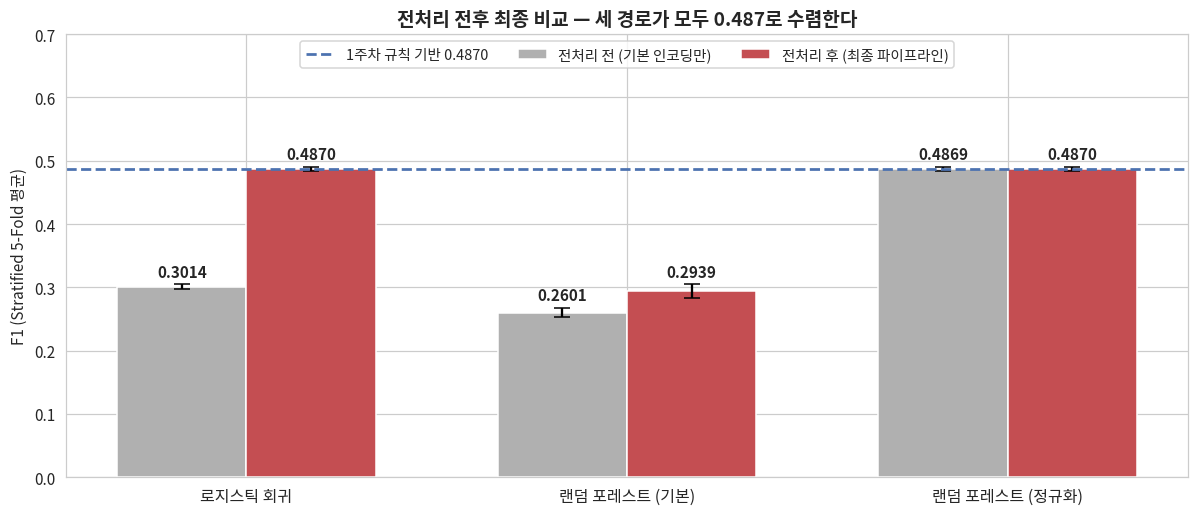

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8))
mods = ORDER; x = np.arange(len(mods)); w = .34
for i, cfg in enumerate(final_tbl['설정'].unique()):
    s = final_tbl[final_tbl['설정'] == cfg]
    vals = [s[s['모델']==m]['F1 평균'].iloc[0] for m in mods]
    errs = [s[s['모델']==m]['F1 표준편차'].iloc[0] for m in mods]
    bars = ax.bar(x+(i-.5)*w, vals, w, yerr=errs, capsize=5, color=['#B0B0B0','#C44E52'][i], label=cfg)
    for bb, v, e in zip(bars, vals, errs):
        ax.text(bb.get_x()+bb.get_width()/2, v+e+.012, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0.4870, color='#4C72B0', ls='--', lw=1.8, label='1주차 규칙 기반 0.4870')
ax.set_xticks(x); ax.set_xticklabels(mods, fontsize=10.5)
ax.set_ylim(0, .70); ax.set_ylabel('F1 (Stratified 5-Fold 평균)'); ax.legend(fontsize=9.5, loc='upper center', ncol=3)
ax.set_title('전처리 전후 최종 비교 — 세 경로가 모두 0.487로 수렴한다', fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.savefig('figures/fig06_final.png'); plt.show()

In [13]:
# 전처리 결과 저장 (3주차에서 사용)
X_train.assign(Cancer=y.values).to_csv('train_preprocessed.csv', index=False)
X_test.assign(ID=test[ID].values).to_csv('test_preprocessed.csv', index=False)
print('저장 완료: train_preprocessed.csv / test_preprocessed.csv')

저장 완료: train_preprocessed.csv / test_preprocessed.csv


## 최종 검증 결과

| 설정 | 모델 | F1 (5-Fold 평균 ± 표준편차) |
|:--|:--|--:|
| 전처리 전 | 로지스틱 회귀 | 0.3014 ± 0.0035 |
| **전처리 후** | **로지스틱 회귀** | **0.4870 ± 0.0035** |
| 전처리 전 | 랜덤 포레스트 (기본) | 0.2601 ± 0.0075 |
| 전처리 후 | 랜덤 포레스트 (기본) | 0.2939 ± 0.0107 |
| 전처리 전 | 랜덤 포레스트 (정규화) | **0.4869 ± 0.0036** |
| 전처리 후 | 랜덤 포레스트 (정규화) | **0.4870 ± 0.0035** |

### (1) 전처리로 로지스틱 회귀가 +0.1856 상승했다

0.3014 → 0.4870, 상대적으로 **61.6% 향상**이다. 폴드 간 표준편차가 0.0035로 매우 작아 우연이 아니다.

### (2) 서로 다른 세 경로가 모두 0.487에 도달했다 — 구조적 상한의 증거

| 접근 | F1 |
|:--|--:|
| 1주차 · 조건문 3줄 (학습 없음) | 0.4870 |
| 2주차 · 로지스틱 회귀 + Feature Engineering | 0.4870 |
| 2주차 · 정규화 랜덤 포레스트 (**FE 없이**) | 0.4869 |

완전히 다른 세 방법이 소수점 넷째 자리까지 같은 값에 수렴했다. 이는 우연이 아니라 **이 데이터가 담고 있는 정보의 총량이 정확히 여기까지**라는 뜻이다. 1주차에서 "전체 양성의 53.9%는 예측 불가능한 잡음"이라고 추정했던 것이 실측으로 확인됐다.

### (3) Feature Engineering의 진짜 역할

정규화한 랜덤 포레스트는 **파생변수 없이 원본 인코딩만으로 0.4869**를 냈다. 트리는 조건 분기를 중첩할 수 있어 상호작용을 스스로 발견할 수 있기 때문이다.

즉 Feature Engineering은 **새로운 정보를 만들어낸 것이 아니라, 이미 데이터에 있던 구조를 선형 모델이 접근할 수 있는 형태로 번역한 것**이다.

| 모델 | 상호작용에 도달하는 방법 |
|:--|:--|
| 로지스틱 회귀 (선형) | AND 조건을 표현할 수 없음 → **사람이 만들어 줘야 함** |
| 랜덤 포레스트 (트리) | 분기를 중첩해 스스로 발견 → **단, 과적합을 막는 정규화가 필요** |

### (4) 기본 랜덤 포레스트가 나빴던 이유

깊이 제한이 없으면 89.3%를 차지하는 기저 그룹의 순수한 잡음까지 외운다. `max_depth=16`, `min_samples_leaf=10`을 주는 것만으로 **0.2601 → 0.4869 (+0.2268)**로 뛰었다. 3주차 하이퍼파라미터 튜닝의 출발점이 여기서 정해졌다.

---
# 마무리

## 이번 주차 전처리 요약

| # | 항목 | 적용 여부 | 결정과 근거 |
|:--|:--|:--|:--|
| 1 | 결측치 | **미적용** | 실제 0건. 인위적 주입 실험으로 5개 기법을 비교했고, 향후 원칙(수치형 중앙값 / 범주형 별도 범주)을 수립했다 |
| 2 | 이상치 | **미적용** | IQR·Z-score 기준 모두 0건. 균등분포에서 \|z\|는 √3을 넘을 수 없음을 수식으로 증명했다. 강제 클리핑 시 7.51%가 훼손되고 F1은 +0.0002 |
| 3 | 인코딩 | **적용** | Binary(이진 7개) + One-Hot(`Country`, `Race`). Label은 가짜 순서로 F1이 0.0388 하락, Target은 누수 위험 |
| 4 | Scaling | **적용** | MinMaxScaler(수치형 5개). 로지스틱 학습 11배 단축, KNN은 0.0000 → 0.1312. 트리 모델엔 무관 |
| 5 | Feature Eng. | **적용** | 상호작용 3개 + n_risk + is_high_risk. **F1 +0.1711** — 이번 주차 성능의 전부 |

## 이번 주차에서 배운 것

**전처리는 정보를 늘리는 작업이 아니라, 이미 있는 정보를 모델이 쓸 수 있는 형태로 바꾸는 작업이다.**

- 결측치·이상치 처리는 적용 대상이 없었고, 억지로 적용하면 손해만 봤다
- 인코딩과 스케일링은 "성능을 올린다"기보다 **모델이 오작동하지 않게 하는 최소 조건**이었다 (KNN F1 0.0000이 그 증거)
- Feature Engineering만이 유일하게 큰 성능 변화를 만들었는데, 그마저도 **정규화한 트리 모델은 없이도 같은 지점에 도달**했다

## 3주차로 넘기는 과제

1. **하이퍼파라미터 튜닝** — `max_depth=16`, `min_samples_leaf=10`이라는 임의의 값으로도 +0.2268을 얻었다. 체계적인 탐색이 필요하다
2. **임계값(threshold) 조정** — 기본 0.5가 F1 최적이 아닐 수 있다. Precision-Recall 곡선에서 최대 지점을 찾는다
3. **성능 상한 인식** — 세 가지 독립적인 접근이 모두 0.487에 수렴했다. 이 벽을 크게 넘는 결과가 나온다면 **먼저 데이터 누수를 의심**해야 한다

---

## 참고 문헌

1. scikit-learn developers. "Preprocessing data — User Guide." <https://scikit-learn.org/stable/modules/preprocessing.html>
2. scikit-learn developers. "Imputation of missing values." <https://scikit-learn.org/stable/modules/impute.html>
3. scikit-learn developers. "Importance of Feature Scaling." <https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html>
4. Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
5. Micci-Barreca, D. (2001). "A Preprocessing Scheme for High-Cardinality Categorical Attributes in Classification and Prediction Problems." *ACM SIGKDD Explorations*, 3(1), 27–32. <https://dl.acm.org/doi/10.1145/507533.507538>
6. Kaufman, S., Rosset, S., & Perlich, C. (2012). "Leakage in Data Mining: Formulation, Detection, and Avoidance." *ACM TKDD*, 6(4). <https://dl.acm.org/doi/10.1145/2382577.2382579>
7. Zheng, A., & Casari, A. (2018). *Feature Engineering for Machine Learning*. O'Reilly Media.
8. Kuhn, M., & Johnson, K. (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models*. CRC Press. <http://www.feat.engineering/>
9. DACON. "갑상선암 진단 분류 해커톤." <https://dacon.io/competitions/official/236488/overview/description>
10. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
